In [8]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import itertools

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, FunctionTransformer, OneHotEncoder, LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.svm import SVC


import warnings
warnings.filterwarnings("ignore")

random_state = 777

In [9]:
url = "https://raw.githubusercontent.com/guille1006/TFM/refs/heads/main/data/data_complete.csv"
df = pd.read_csv(url)

In [10]:
y = df["price"]
X = df.drop(columns="price")

variables_bool = [a for a in X.columns if X[a].nunique(dropna=False) <3]

variables_num = X.select_dtypes(include=["number"]).columns.tolist()

categoricas = []
for col in df.columns:
    if df[col].dtypes == "object":
        if df[col].nunique(dropna=False) <20:
            categoricas.append(col)
df[categoricas] = df[categoricas].astype("category")
variables_cat = df.select_dtypes(include=["category"]).columns.tolist()

print(f"{"variable_bool":50}{"variables_num":<50}{"variables_cat":<10}")
print("------------------------------------------------------------------------------------------------------------------------")
for variable in itertools.zip_longest(variables_bool, variables_num, variables_cat, fillvalue=""): 
    print(f"{variable[0]:50}{variable[1]:<45}{variable[2]:<10}")

variable_bool                                     variables_num                                     variables_cat
------------------------------------------------------------------------------------------------------------------------
exterior                                          bathrooms                                    detailedType.subTypology
has360                                            floor                                        detailedType.typology
has3DTour                                         numPhotos                                    highlight.groupDescription
hasLift                                           parkingSpace.parkingSpacePrice               propertyType
hasPlan                                           priceByArea                                  status    
hasStaging                                        priceInfo.price.priceDropInfo.priceDropPercentagefloor_cat 
hasVideo                                          rooms                           

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state)

In [19]:
preprocessor = ColumnTransformer(
    transformers = [
        ("num_transf", StandardScaler(), variables_num),
        ("cat_transf", OneHotEncoder(handle_unknown="ignore"), variables_cat)
    ]
)

pipeline = Pipeline(
    [
        ("preprocessor", preprocessor),
        ("estimator", SVC())
    ]
)

param_grid = {
    'estimator__C': [0.1, 1, 10],
    'estimator__kernel': ['linear', 'rbf'],
    'estimator__gamma': [0.001, 0.01, 0.1, 1, 'scale', 'auto']
}

cv = KFold(n_splits=5)

scoring = {
    'MAE': 'neg_mean_absolute_error',
    'MSE': 'neg_mean_squared_error',
    'R2': 'r2'
}

grid_search = GridSearchCV(
    estimator=pipeline, 
    param_grid=param_grid, 
    cv=cv, 
    scoring=scoring, 
    refit='MAE',
    verbose=2
)


In [20]:
grid_search.fit(X_test, y_test)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
[CV] END estimator__C=0.1, estimator__gamma=0.001, estimator__kernel=linear; total time=  14.3s
[CV] END estimator__C=0.1, estimator__gamma=0.001, estimator__kernel=linear; total time=  15.0s
[CV] END estimator__C=0.1, estimator__gamma=0.001, estimator__kernel=linear; total time=  14.6s
[CV] END estimator__C=0.1, estimator__gamma=0.001, estimator__kernel=linear; total time=  14.2s
[CV] END estimator__C=0.1, estimator__gamma=0.001, estimator__kernel=linear; total time=  14.6s
[CV] END estimator__C=0.1, estimator__gamma=0.001, estimator__kernel=rbf; total time=  13.4s
[CV] END estimator__C=0.1, estimator__gamma=0.001, estimator__kernel=rbf; total time=  13.8s
[CV] END estimator__C=0.1, estimator__gamma=0.001, estimator__kernel=rbf; total time=  13.7s
[CV] END estimator__C=0.1, estimator__gamma=0.001, estimator__kernel=rbf; total time=  13.8s
[CV] END estimator__C=0.1, estimator__gamma=0.001, estimator__kernel=rbf; total time= 

,estimator,"Pipeline(step...tor', SVC())])"
,param_grid,"{'estimator__C': [0.1, 1, ...], 'estimator__gamma': [0.001, 0.01, ...], 'estimator__kernel': ['linear', 'rbf']}"
,scoring,"{'MAE': 'neg_mean_absolute_error', 'MSE': 'neg_mean_squared_error', 'R2': 'r2'}"
,n_jobs,None
,refit,'MAE'
,cv,KFold(n_split...shuffle=False)
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num_transf', ...), ('cat_transf', ...)]"


In [22]:
results_df = pd.DataFrame(grid_search.cv_results_).head(10)
results_df


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_estimator__C,param_estimator__gamma,param_estimator__kernel,params,split0_test_MAE,split1_test_MAE,...,std_test_MSE,rank_test_MSE,split0_test_R2,split1_test_R2,split2_test_R2,split3_test_R2,split4_test_R2,mean_test_R2,std_test_R2,rank_test_R2
0,4.974619,0.266365,9.674620,0.241585,0.1,0.001,linear,"{'estimator__C': 0.1, 'estimator__gamma': 0.00...",-420332.988555,-353066.648069,...,2.004888e+11,17,0.485301,0.666641,0.512299,0.643588,0.439332,0.549432,0.089685,17
1,4.549531,0.097810,9.136063,0.117657,0.1,0.001,rbf,"{'estimator__C': 0.1, 'estimator__gamma': 0.00...",-540081.477825,-953827.263233,...,2.556357e+11,34,0.140588,-0.090233,-0.041585,0.086782,-0.031147,0.012881,0.086380,34
2,4.849203,0.661187,9.769259,0.573125,0.1,0.01,linear,"{'estimator__C': 0.1, 'estimator__gamma': 0.01...",-420332.988555,-353066.648069,...,2.004888e+11,17,0.485301,0.666641,0.512299,0.643588,0.439332,0.549432,0.089685,17
3,4.219203,0.096543,9.192813,0.193473,0.1,0.01,rbf,"{'estimator__C': 0.1, 'estimator__gamma': 0.01...",-537272.608011,-953827.263233,...,2.601115e+11,33,0.143860,-0.090233,-0.041585,0.115225,-0.031147,0.019224,0.092700,33
4,4.206008,0.065404,9.445398,0.149633,0.1,0.1,linear,"{'estimator__C': 0.1, 'estimator__gamma': 0.1,...",-420332.988555,-353066.648069,...,2.004888e+11,17,0.485301,0.666641,0.512299,0.643588,0.439332,0.549432,0.089685,17
5,4.736736,0.130391,9.185673,0.093654,0.1,0.1,rbf,"{'estimator__C': 0.1, 'estimator__gamma': 0.1,...",-580790.467811,-694108.379113,...,2.117299e+11,31,0.129149,0.086193,-0.041585,0.151147,-0.031147,0.058751,0.080492,31
6,4.112811,0.086688,9.393547,0.087761,0.1,1,linear,"{'estimator__C': 0.1, 'estimator__gamma': 1, '...",-420332.988555,-353066.648069,...,2.004888e+11,17,0.485301,0.666641,0.512299,0.643588,0.439332,0.549432,0.089685,17
7,5.225979,0.027368,9.167024,0.130020,0.1,1,rbf,"{'estimator__C': 0.1, 'estimator__gamma': 1, '...",-792515.346209,-953827.263233,...,2.957217e+11,36,0.034873,-0.090233,-0.041585,0.015908,-0.031147,-0.022437,0.044257,36
8,4.080800,0.057994,9.441631,0.149840,0.1,scale,linear,"{'estimator__C': 0.1, 'estimator__gamma': 'sca...",-420332.988555,-353066.648069,...,2.004888e+11,17,0.485301,0.666641,0.512299,0.643588,0.439332,0.549432,0.089685,17
9,4.551208,0.146342,9.208405,0.131595,0.1,scale,rbf,"{'estimator__C': 0.1, 'estimator__gamma': 'sca...",-568107.062947,-652618.379113,...,2.040916e+11,30,0.133967,0.113338,-0.041585,0.152777,-0.031147,0.065470,0.084145,30


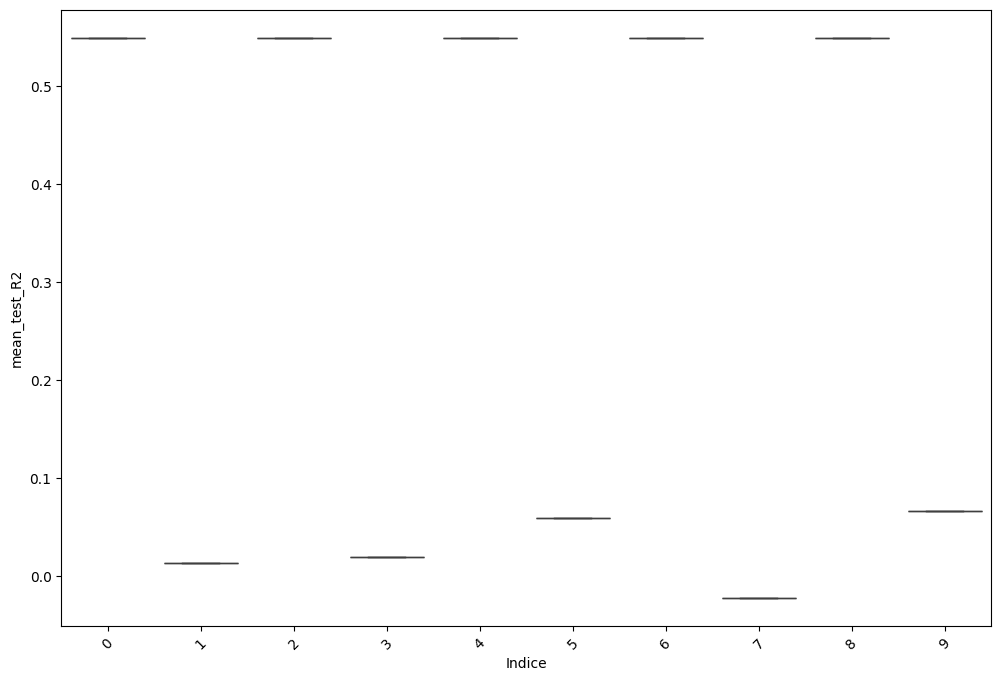

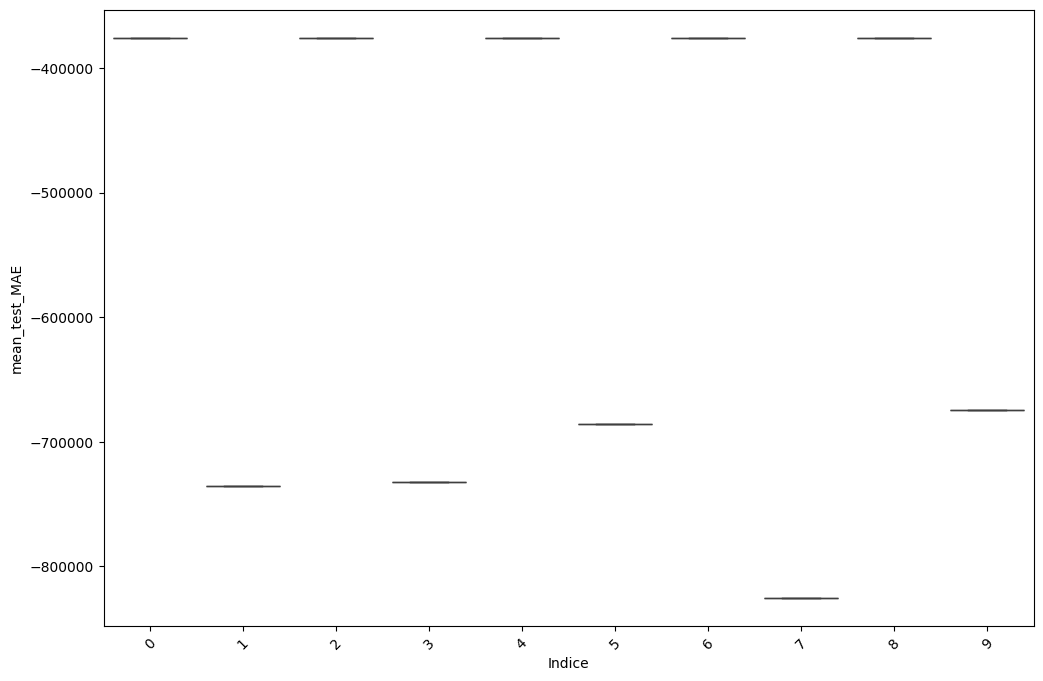

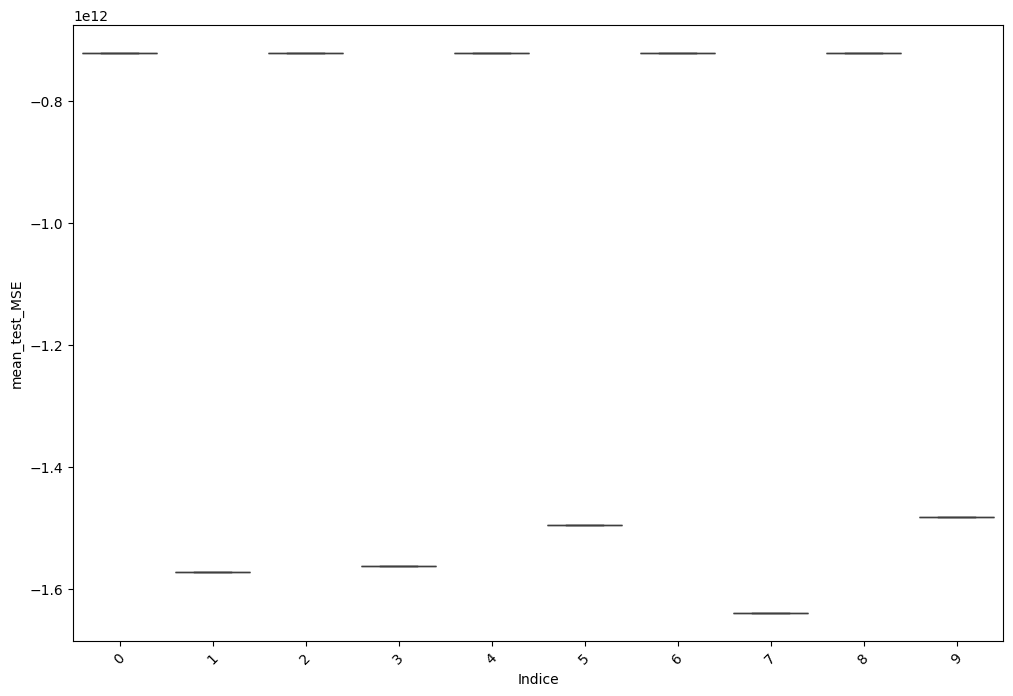

In [23]:


# Graficar los scores según los parámetros
for score in ["mean_test_R2", "mean_test_MAE", "mean_test_MSE"]:
    plt.figure(figsize=(12, 8))
    sns.boxplot(x=results_df.index, y=score, data=results_df)
    plt.ylabel(score)
    plt.xlabel("Indice")
    plt.xticks(rotation=45)
    plt.show()